# Nanograd Tutorial & Examples

Welcome to the **Nanograd** tutorial! 

`nanograd` is a lightweight, PyTorch-like autograd engine that implements reverse-mode automatic differentiation over multi-dimensional arrays (tensors) using `NumPy`. It also provides modular neural network building blocks, loss functions, and optimizers.

In this notebook, we will explore:
1. **Basic Tensors & Backpropagation**: Creating tensors, performing mathematical operations, and executing backward passes.
2. **Training a Multi-Layer Perceptron (MLP)**: Training an MLP on a non-linear 2D classification dataset (Moons/Circles) and visualizing the decision boundary.
3. **Advanced Layers (CNN Components)**: Using Convolution (`Conv2D`), Max Pooling (`MaxPool2D`), and `Flatten` layers to process images.

---

In [12]:
# Enable importing nanograd from parent directory
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

# Import the core components of nanograd
from nanograd import Tensor, MLP, SGD, MSE, relu
from nanograd.optim import Adam
from nanograd.loss import SoftmaxCrossEntropy
from nanograd.nn import Conv2D, MaxPool2D, Flatten, softmax

# Set random seed for reproducibility
np.random.seed(42)

## 1. Basic Tensors & Backpropagation

In `nanograd`, a `Tensor` wraps a `numpy.ndarray` and tracks mathematical operations to build a computation graph (DAG). 

Let's define a few tensors and compute a simple expression:
$$f(x, y, z) = (x \cdot y + z)^2$$

In [13]:
# 1. Initialize input tensors
x = Tensor(np.array([[2.0, -1.0], [3.0, 1.5]]), label='x')
y = Tensor(np.array([[1.5, 2.0], [-0.5, 2.0]]), label='y')
z = Tensor(np.array([[0.5, 1.0], [1.0, -1.0]]), label='z')

print("x:\n", x.data)
print("y:\n", y.data)
print("z:\n", z.data)

x:
 [[ 2.  -1. ]
 [ 3.   1.5]]
y:
 [[ 1.5  2. ]
 [-0.5  2. ]]
z:
 [[ 0.5  1. ]
 [ 1.  -1. ]]


Now, let's perform operations to build the computation graph.

In [14]:
# 2. Forward pass: f = (x * y + z) ** 2
a = x * y
b = a + z
f = b ** 2

print("Forward pass output (f):\n", f.data)

Forward pass output (f):
 [[12.25  1.  ]
 [ 0.25  4.  ]]


To compute the gradients of $f$ with respect to $x$, $y$, and $z$, we simply call `.backward()` on the output tensor $f$.
This will:
1. Sort the computation graph topologically (so parents are processed after children).
2. Propagate the gradients backward using the chain rule.

In [15]:
# 3. Backward pass
f.backward()

# 4. Inspect the computed gradients
print("Gradient w.r.t x (df/dx):\n", x.grad)
print("Gradient w.r.t y (df/dy):\n", y.grad)
print("Gradient w.r.t z (df/dz):\n", z.grad)

Gradient w.r.t x (df/dx):
 [[10.5 -4. ]
 [ 0.5  8. ]]
Gradient w.r.t y (df/dy):
 [[14.  2.]
 [-3.  6.]]
Gradient w.r.t z (df/dz):
 [[ 7. -2.]
 [-1.  4.]]


We can verify the gradients manually:
$$b = x \cdot y + z$$
$$f = b^2$$
$$\frac{\partial f}{\partial f} = 1$$
$$\frac{\partial f}{\partial b} = 2b$$
$$\frac{\partial f}{\partial z} = \frac{\partial f}{\partial b} \cdot \frac{\partial b}{\partial z} = 2b \cdot 1 = 2(x \cdot y + z)$$
$$\frac{\partial f}{\partial x} = \frac{\partial f}{\partial b} \cdot \frac{\partial b}{\partial x} = 2(x \cdot y + z) \cdot y$$

Let's double-check the gradient of $x$ at $[0, 0]$:
$$x_{0,0} = 2.0, y_{0,0} = 1.5, z_{0,0} = 0.5$$
$$b_{0,0} = 2.0 \cdot 1.5 + 0.5 = 3.5$$
$$\frac{\partial f}{\partial x_{0,0}} = 2 \cdot 3.5 \cdot 1.5 = 10.5$$

And indeed, the gradient in `x.grad` at $[0,0]$ is $10.5$!

## 2. Training a Multi-Layer Perceptron (MLP) on a Non-Linear Dataset

Let's solve a binary classification task. We will generate a non-linear dataset consisting of concentric circles (points in a ring vs. points in a center disk), define a custom neural network, train it using Adam/SGD optimizer, and visualize the decision boundary.

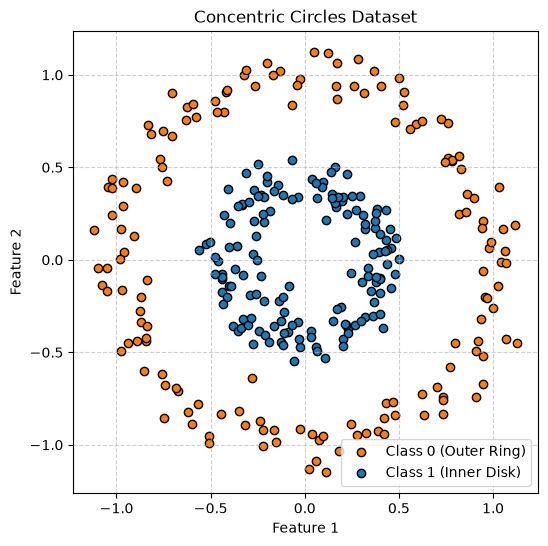

In [16]:
def make_circles(n_samples=200, noise=0.1, factor=0.5):
    """
    Generates a 2D dataset of concentric circles.
    """
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out
    
    # Outer circle
    theta_out = np.linspace(0, 2 * np.pi, n_samples_out)
    X_out = np.stack([np.cos(theta_out), np.sin(theta_out)], axis=1)
    
    # Inner circle
    theta_in = np.linspace(0, 2 * np.pi, n_samples_in)
    X_in = np.stack([np.cos(theta_in), np.sin(theta_in)], axis=1) * factor
    
    X = np.vstack([X_out, X_in])
    y = np.hstack([np.zeros(n_samples_out), np.ones(n_samples_in)])
    
    # Add noise
    X += np.random.normal(scale=noise, size=X.shape)
    
    # Reshape y to (n_samples, 1)
    y = y.reshape(-1, 1)
    return X, y

# Generate data
X_np, y_np = make_circles(n_samples=300, noise=0.08, factor=0.4)

# Visualize dataset
plt.figure(figsize=(6, 6))
plt.scatter(X_np[y_np.flatten() == 0, 0], X_np[y_np.flatten() == 0, 1], c='#ff7f0e', label='Class 0 (Outer Ring)', edgecolors='k')
plt.scatter(X_np[y_np.flatten() == 1, 0], X_np[y_np.flatten() == 1, 1], c='#1f77b4', label='Class 1 (Inner Disk)', edgecolors='k')
plt.title("Concentric Circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Defining the Model, Loss, and Optimizer

We will build a simple Multi-Layer Perceptron (MLP) with the following structure:
- **Input**: 2 dimensions (our $X_1, X_2$ features)
- **Hidden Layer 1**: 16 neurons with ReLU activation
- **Hidden Layer 2**: 16 neurons with ReLU activation
- **Output Layer**: 1 neuron (linear activation for regression/output logits)

### Essential Design Enhancements:
1. **Linear output activation**: The default MLP implementation forces the output layer to use ReLU. This can restrict predictions to positive values, causing output neurons to die. We manually override the last layer's activation function to linear (identity).
2. **He (Kaiming) weight initialization**: We initialize the weights using He normal distribution ($W \sim \mathcal{N}(0, \sqrt{2/n_{in}})$) and set biases to zero. This ensures stable gradients and prevents dying neurons from the start.

In [17]:
# Wrap dataset in Tensors
X_tensor = Tensor(X_np)
y_tensor = Tensor(y_np)

# Define MLP architecture: 2 inputs -> 16 hidden -> 16 hidden -> 1 output
model = MLP([2, 16, 16, 1])

# Override last layer activation to identity (linear output)
model.layers[-1].activation_function = lambda x: x

# Apply He initialization to weights and zero to biases
for layer in model.layers:
    layer.weights.data = np.random.normal(0, np.sqrt(2.0 / layer.num_inputs), size=layer.weights.data.shape)
    layer.bias.data = np.zeros(layer.bias.data.shape)

# Initialize Optimizer (Adam) and Loss (MSE)
optimizer = Adam(model.params(), learning_rate=0.01)
criterion = MSE()

print(f"Number of parameter tensors: {len(model.params())}")

Number of parameter tensors: 6


### Training Loop

We will train the MLP for 150 epochs.
In each epoch, we:
1. Perform a forward pass through the model.
2. Calculate the loss between predictions and target labels.
3. Reset parameter gradients to zero.
4. Execute backpropagation using `loss.backward()`.
5. Update model weights using `optimizer.step()`.

Epoch   1/150 | MSE Loss: 1.988433
Epoch  15/150 | MSE Loss: 0.324273
Epoch  30/150 | MSE Loss: 0.177679
Epoch  45/150 | MSE Loss: 0.040542
Epoch  60/150 | MSE Loss: 0.022573
Epoch  75/150 | MSE Loss: 0.016081
Epoch  90/150 | MSE Loss: 0.014457
Epoch 105/150 | MSE Loss: 0.013498
Epoch 120/150 | MSE Loss: 0.013071
Epoch 135/150 | MSE Loss: 0.012652
Epoch 150/150 | MSE Loss: 0.012168


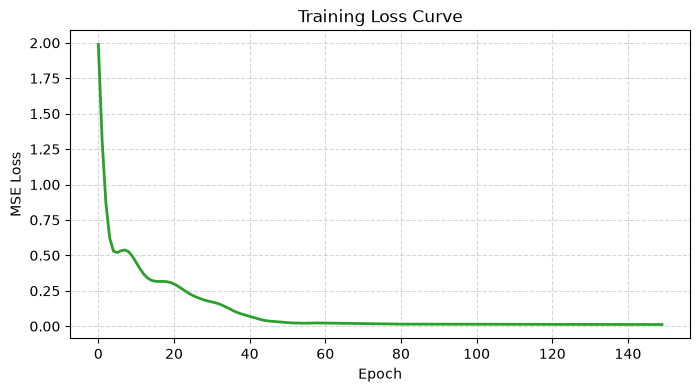

In [18]:
epochs = 150
loss_history = []

for epoch in range(epochs):
    # 1. Forward pass
    y_pred = model(X_tensor)
    
    # 2. Calculate Mean Squared Error loss
    loss = criterion(y_pred, y_tensor)
    loss_history.append(loss.data.item())
    
    # 3. Reset gradients
    optimizer.zero_grad()
    
    # 4. Backward pass
    loss.backward()
    
    # 5. Parameter update step
    optimizer.step()
    
    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | MSE Loss: {loss.data.item():.6f}")

# Plot learning curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#2ca02c', linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Visualizing the Decision Boundary

Let's see how our trained `nanograd` MLP splits the 2D plane to separate the circles.

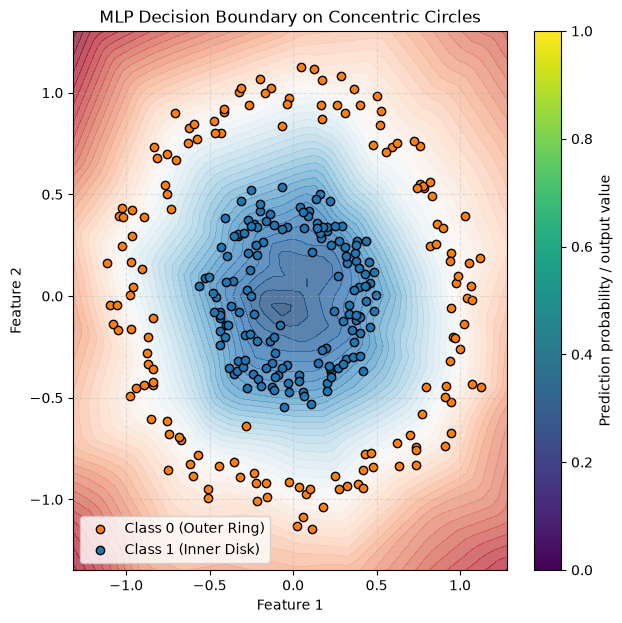

In [19]:
# Generate a grid of points covering the feature space
x_min, x_max = X_np[:, 0].min() - 0.2, X_np[:, 0].max() + 0.2
y_min, y_max = X_np[:, 1].min() - 0.2, X_np[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Flatten grid points for evaluation
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = Tensor(grid_points)

# Get network predictions for the grid
Z = model(grid_tensor).data
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)
plt.scatter(X_np[y_np.flatten() == 0, 0], X_np[y_np.flatten() == 0, 1], c='#ff7f0e', label='Class 0 (Outer Ring)', edgecolors='k')
plt.scatter(X_np[y_np.flatten() == 1, 0], X_np[y_np.flatten() == 1, 1], c='#1f77b4', label='Class 1 (Inner Disk)', edgecolors='k')
plt.title("MLP Decision Boundary on Concentric Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Prediction probability / output value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 3. Advanced Neural Networks (CNN Components)

`nanograd` also implements operations for convolutional neural networks:
- **`Conv2D`**: 2D convolution layer mapping input channel channels to output filters using `im2col` under the hood.
- **`MaxPool2D`**: Max pooling operation to downsample spatial dimensions.
- **`Flatten`**: Reshaping 4D spatial tensors `(N, C, H, W)` into 2D feature matrices `(N, C * H * W)`.

Let's test these layers by building a mini convolutional pipeline and executing a backward pass.

In [20]:
# Create a synthetic batch of images: batch_size = 2, channels = 1 (grayscale), size = 8x8
# e.g., representing simple binary shape patterns
img_batch = np.random.uniform(0.0, 1.0, size=(2, 1, 8, 8))
x_img = Tensor(img_batch, label='input_image')

print("Input shape:", x_img.shape())

Input shape: (2, 1, 8, 8)


Let's pass the image batch through a sequence of CNN layers:
1. **`Conv2D`**: `in_channels=1`, `num_filters=2`, `kernel_size=(3,3)`, `padding=1`, `stride=1`
2. **`relu`**: non-linear activation
3. **`MaxPool2D`**: `kernel_size=(2,2)`, `stride=2` (downsamples $8\times8$ to $4\times4$)
4. **`Flatten`**: flattens spatial channels to vector representations

In [21]:
# Initialize layers
conv = Conv2D(in_channels=1, num_filters=2, kernel_size=(3, 3), padding=1, stride=1)
pool = MaxPool2D(kernel_size=(2, 2), stride=2)
flatten = Flatten()

# Forward pass
h_conv = conv(x_img)
h_relu = relu(h_conv)
h_pool = pool(h_relu)
out = flatten(h_pool)

print("Shape after Conv2D:   ", h_conv.shape())
print("Shape after MaxPool2D:", h_pool.shape())
print("Shape after Flatten:  ", out.shape())

Shape after Conv2D:    (2, 2, 8, 8)
Shape after MaxPool2D: (2, 2, 4, 4)
Shape after Flatten:   (2, 32)


Now, let's calculate a dummy loss (sum of all outputs) and perform backpropagation to compute gradients for the `Conv2D` layer parameters.

In [22]:
# Compute dummy loss
loss = out.sum()

# Backward pass
loss.backward()

# Check gradients of Conv2D layer
print("Conv2D weights shape: ", conv.weights.shape())
print("Conv2D weights grad (norm):", np.linalg.norm(conv.weights.grad))
print("Conv2D bias shape:    ", conv.bias.shape())
print("Conv2D bias grad:     ", conv.bias.grad)

Conv2D weights shape:  (2, 1, 9)
Conv2D weights grad (norm): 56.5908185631864
Conv2D bias shape:     (1, 2)
Conv2D bias grad:      [[32. 25.]]


### Summary

You have successfully explored the core features of **Nanograd**:
- Created mathematical expressions on **Tensors** and calculated analytical gradients automatically.
- Trained a **Multi-Layer Perceptron (MLP)** using the Adam optimizer to separate non-linear data.
- Built a convolutional block using `Conv2D`, `MaxPool2D`, and `Flatten` and computed gradients through it.

Feel free to customize these models, write custom loss functions, or try different activation functions to explore deep learning from the ground up!